# Task 4: Insights and Recommendations

This notebook transforms sentiment and thematic analysis into actionable business insights for Ethiopian banks:
- Commercial Bank of Ethiopia (CBE)
- Bank of Abyssinia (BOA)
- Dashen Bank

We analyze customer sentiment, ratings, and themes to identify:
- Satisfaction drivers
- Pain points
- Cross-bank comparisons
- Product improvement opportunities

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

df = pd.read_csv("../data/analyzed/processed_reviews.csv")

df.head()

,review,rating,date,bank,source,sentiment_label,sentiment_score,processed_review
0,wow,4,2026-05-14,CBE,Google Play,POSITIVE,0.999592,wow
1,nice app,5,2026-05-14,CBE,Google Play,POSITIVE,0.999806,nice app
2,formative,5,2026-05-14,CBE,Google Play,POSITIVE,0.998885,formative
3,best app for financial activities 🙌,5,2026-05-14,CBE,Google Play,POSITIVE,0.996808,good app financial activity
4,yoroo namaste 🙏 ♥️ ❤️ 💖 💖,5,2026-05-14,CBE,Google Play,NEGATIVE,0.890468,yoroo namaste


In [16]:
def identify_theme(text):

    text = str(text).lower()

    if any(word in text for word in [
        "login", "password", "otp", "access"
    ]):
        return "Account Access Issues"

    elif any(word in text for word in [
        "transfer", "slow", "transaction", "payment"
    ]):
        return "Transaction Performance"

    elif any(word in text for word in [
        "ui", "design", "interface", "easy"
    ]):
        return "UI & Design"

    elif any(word in text for word in [
        "support", "service", "help"
    ]):
        return "Customer Support"

    elif any(word in text for word in [
        "feature", "fingerprint", "update"
    ]):
        return "Feature Requests"

    else:
        return "Other"


df["identified_theme"] = df[
    "processed_review"
].apply(identify_theme)

df.head()

,review,rating,date,bank,source,sentiment_label,sentiment_score,processed_review,identified_theme
0,wow,4,2026-05-14,CBE,Google Play,POSITIVE,0.999592,wow,Other
1,nice app,5,2026-05-14,CBE,Google Play,POSITIVE,0.999806,nice app,Other
2,formative,5,2026-05-14,CBE,Google Play,POSITIVE,0.998885,formative,Other
3,best app for financial activities 🙌,5,2026-05-14,CBE,Google Play,POSITIVE,0.996808,good app financial activity,Other
4,yoroo namaste 🙏 ♥️ ❤️ 💖 💖,5,2026-05-14,CBE,Google Play,NEGATIVE,0.890468,yoroo namaste,Other


## Satisfaction Drivers and Pain Points

We identify at least:
- 2 satisfaction drivers per bank
- 2 pain points per bank

based on sentiment patterns, themes, and review content.

In [23]:
df["sentiment_label"] = df["sentiment_label"].str.upper()

In [24]:
for bank in df["bank"].unique():
    print("\n====================", bank, "====================")

    bank_df = df[df["bank"] == bank]

    print("\nTop Positive Themes:")
    print(
        bank_df[bank_df["sentiment_label"] == "POSITIVE"]["identified_theme"]
        .value_counts()
        .head(3)
    )

    print("\nTop Negative Themes:")
    print(
        bank_df[bank_df["sentiment_label"] == "NEGATIVE"]["identified_theme"]
        .value_counts()
        .head(3)
    )


==================== CBE ====================

Top Positive Themes:
identified_theme
Other               243
UI & Design          14
Customer Support     13
Name: count, dtype: int64

Top Negative Themes:
identified_theme
Other                      71
Transaction Performance    19
Feature Requests           14
Name: count, dtype: int64

==================== BOA ====================

Top Positive Themes:
identified_theme
Other               199
Customer Support      8
UI & Design           3
Name: count, dtype: int64

Top Negative Themes:
identified_theme
Other                      140
Transaction Performance     18
Account Access Issues        9
Name: count, dtype: int64

==================== Dashen ====================

Top Positive Themes:
identified_theme
Other                      206
UI & Design                 27
Transaction Performance     11
Name: count, dtype: int64

Top Negative Themes:
identified_theme
Other                      93
Transaction Performance    22
Feature Requ

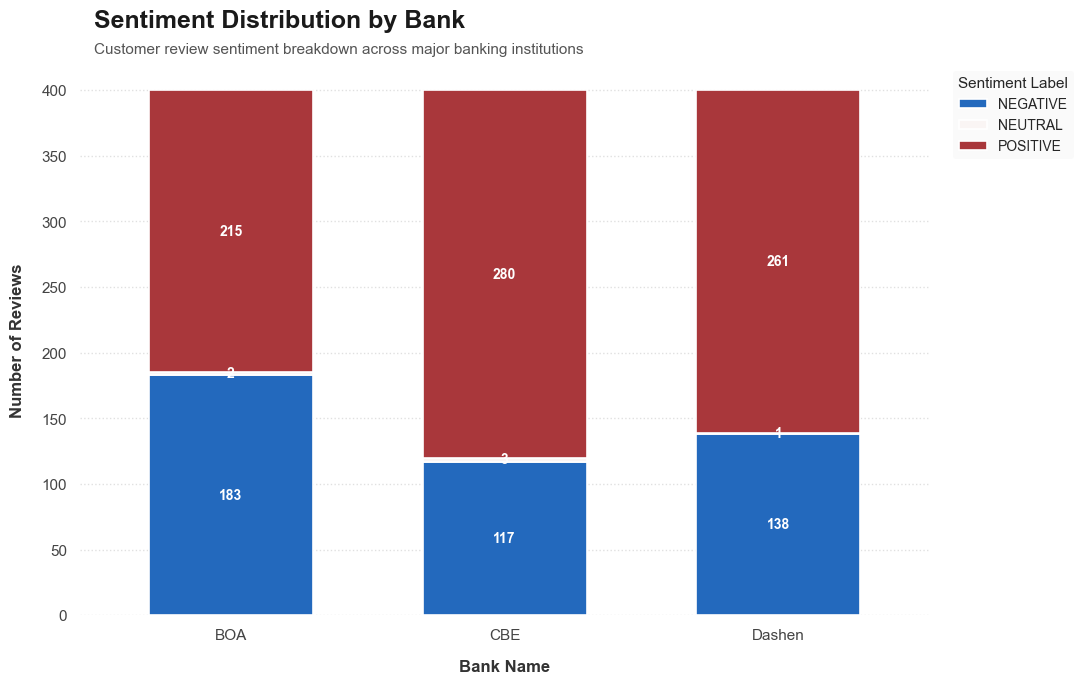

In [28]:
# 1. Set a clean, modern baseline style
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["font.family"] = "sans-serif"  # Uses clean, modern fonts

# 2. Prepare the plot and figure size
fig, ax = plt.subplots(figsize=(11, 7), dpi=100)  # High DPI for crisp text/edges

# 3. Create the stacked bar chart
# Using a tailored palette (e.g., "coolwarm", "Spectral", or a custom list for Negative/Neutral/Positive)
sentiment_dist.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    colormap="vlag",  # A beautiful, balanced divergent palette
    width=0.6,        # Thinner bars look more professional
    edgecolor="white",# Clean white edges instead of harsh black
    linewidth=1.2
)

# 4. Add data labels inside the bars (The ultimate premium touch)
for container in ax.containers:
    # Filter out labels for tiny segments so it doesn't get cluttered
    labels = [f"{int(v):,}" if v > 0 else "" for v in container.datavalues]
    ax.bar_label(
        container, 
        labels=labels, 
        label_type="center", 
        color="white", 
        fontweight="bold", 
        fontsize=10
    )

# 5. Advanced Typography & Titles
# Left-aligned titles look much more modern than centered ones
ax.text(
    x=-0.5, y=sentiment_dist.sum(axis=1).max() * 1.12, 
    s="Sentiment Distribution by Bank", 
    fontsize=18, fontweight="bold", color="#1a1a1a"
)
ax.text(
    x=-0.5, y=sentiment_dist.sum(axis=1).max() * 1.07, 
    s="Customer review sentiment breakdown across major banking institutions", 
    fontsize=11, color="#555555"
)

# 6. Axis Styling & Cleanup
ax.set_xlabel("Bank Name", fontsize=12, fontweight="semibold", labelpad=12, color="#333333")
ax.set_ylabel("Number of Reviews", fontsize=12, fontweight="semibold", labelpad=12, color="#333333")

# Clean up ticks
ax.tick_params(axis="both", which="major", labelsize=11, colors="#444444")
plt.xticks(rotation=0)  # Keep horizontal for readability

# Subtle gridlines (only horizontal)
ax.grid(axis="x", visible=False)
ax.grid(axis="y", linestyle=":", alpha=0.6, color="#cccccc")

# 7. Legend Styling
ax.legend(
    title="Sentiment Label",
    title_fontsize=11,
    fontsize=10,
    loc="upper left",
    bbox_to_anchor=(1.02, 1), # Moves legend outside the plot so it doesn't overlap bars
    frameon=True,
    facecolor="#f9f9f9",
    edgecolor="none"
)

# Strip remaining borders
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()

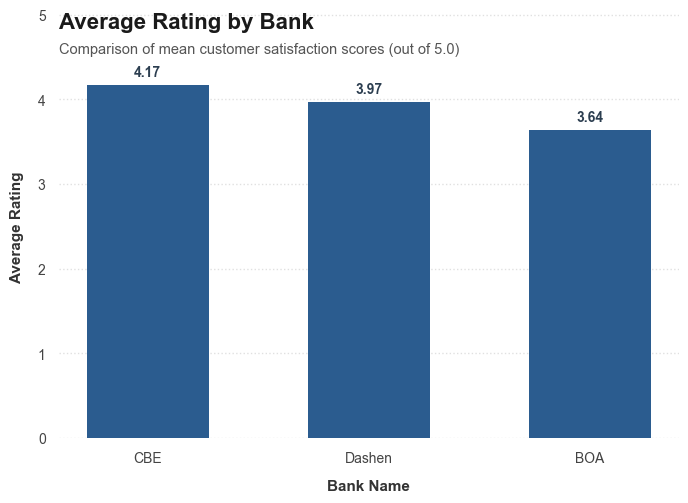

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Group and SORT the data (Crucial for clear visual comparison)
avg_rating = df.groupby("bank")["rating"].mean().sort_values(ascending=False)

# 2. Set a modern, clean baseline style
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["font.family"] = "sans-serif"

# 3. Create the plot and set a high resolution (DPI)
fig, ax = plt.subplots(figsize=(8, 5.5), dpi=100)

# 4. Draw the bar chart
# Using a sophisticated single color (or change to a palette like "Blues_r" if preferred)
bars = ax.bar(
    avg_rating.index, 
    avg_rating.values, 
    color="#2b5c8f",  # Clean, corporate navy/blue
    width=0.55,       # Thinner bars look much more elegant
    edgecolor="none"
)

# 5. Add precise value labels on top of each bar
for bar in bars:
    height = bar.get_height()
    ax.annotate(
        f"{height:.2f}",
        xy=(bar.get_x() + bar.get_width() / 2, height),
        xytext=(0, 4),  # 4 points vertical offset above the bar
        textcoords="offset points",
        ha="center", 
        va="bottom",
        fontsize=10,
        fontweight="bold",
        color="#2c3e50"
    )

# 6. Advanced Typography & Title Hierarchy (Left-aligned)
max_val = avg_rating.max()
ax.text(
    x=-0.4, y=max_val * 1.16, 
    s="Average Rating by Bank", 
    fontsize=16, fontweight="bold", color="#1a1a1a"
)
ax.text(
    x=-0.4, y=max_val * 1.09, 
    s="Comparison of mean customer satisfaction scores (out of 5.0)", 
    fontsize=10.5, color="#555555"
)

# 7. Axis Styling & Cleanup
ax.set_xlabel("Bank Name", fontsize=11, fontweight="semibold", labelpad=10, color="#333333")
ax.set_ylabel("Average Rating", fontsize=11, fontweight="semibold", labelpad=10, color="#333333")

# Adjust y-axis limit dynamically to leave perfect breathing room for labels/titles
ax.set_ylim(0, max_val * 1.2)

# Clean up ticks
ax.tick_params(axis="both", which="major", labelsize=10, colors="#444444")
plt.xticks(rotation=0)  # Keep labels horizontal for instant readability

# Soft dotted horizontal gridlines only
ax.grid(axis="x", visible=False)
ax.grid(axis="y", linestyle=":", alpha=0.6, color="#cccccc")

# Remove unnecessary outer border lines
sns.despine(left=True, bottom=True)

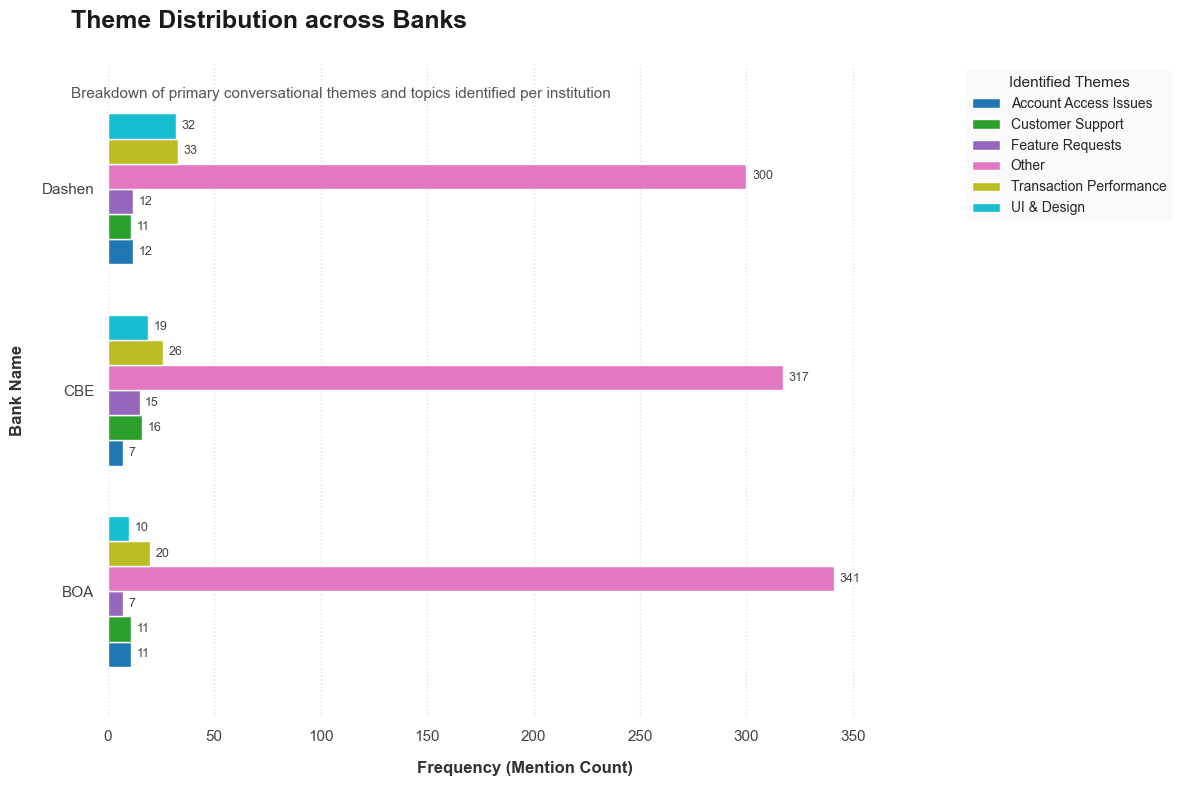

In [32]:
# 1. Prepare data and set a clean, modern style
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["font.family"] = "sans-serif"

# 2. Transpose or structure so it reads beautifully horizontally
# Tip: Sorting by total frequency makes the entire chart flow better
theme_dist = pd.crosstab(df["bank"], df["identified_theme"])
theme_dist = theme_dist.loc[theme_dist.sum(axis=1).sort_values(ascending=True).index]

# 3. Initialize a wider figure for horizontal layout
fig, ax = plt.subplots(figsize=(12, 8), dpi=100)

# 4. Plot as a horizontal bar chart (kind="barh")
# Using a rich, cohesive palette like "Rocket", "Mako", or "viridis_r"
theme_dist.plot(
    kind="barh",
    ax=ax,
    colormap="tab10",   # Great for distinct categorical themes
    width=0.75,         # Gives a balanced look to grouped clusters
    edgecolor="white",  # Crisp white borders between grouped bars
    linewidth=1
)

# 5. Add value labels on the ends of the bars safely
for container in ax.containers:
    # Only show labels for bars with a value greater than 0 to avoid clutter
    labels = [f"{int(v)}" if v > 0 else "" for v in container.datavalues]
    ax.bar_label(
        container,
        labels=labels,
        label_type="edge",    # Places label just outside the end of the bar
        padding=4,            # Soft padding away from the bar edge
        fontsize=9,
        color="#444444"
    )

# 6. Premium Typography & Left-Aligned Layout
# Dynamic positioning based on the number of categories
max_x = theme_dist.values.max()
ax.text(
    x=-max_x * 0.05, y=len(theme_dist) - 0.2, 
    s="Theme Distribution across Banks", 
    fontsize=18, fontweight="bold", color="#1a1a1a"
)
ax.text(
    x=-max_x * 0.05, y=len(theme_dist) - 0.55, 
    s="Breakdown of primary conversational themes and topics identified per institution", 
    fontsize=11, color="#555555"
)

# 7. Clean Axis & Tick Settings
ax.set_ylabel("Bank Name", fontsize=12, fontweight="semibold", labelpad=12, color="#333333")
ax.set_xlabel("Frequency (Mention Count)", fontsize=12, fontweight="semibold", labelpad=12, color="#333333")

# Tick polishing
ax.tick_params(axis="both", which="major", labelsize=11, colors="#444444")

# Soft vertical gridlines only (since the bars are horizontal now!)
ax.grid(axis="y", visible=False)
ax.grid(axis="x", linestyle=":", alpha=0.6, color="#cccccc")

# Extra breathing room on the right side so labels aren't cut off
ax.set_xlim(0, theme_dist.values.max() * 1.15)

# 8. Legend Styling (Moved cleanly to the side)
ax.legend(
    title="Identified Themes",
    title_fontsize=11,
    fontsize=10,
    loc="upper left",
    bbox_to_anchor=(1.02, 1),
    frameon=True,
    facecolor="#f9f9f9",
    edgecolor="none"
)

# Strip remaining heavy borders
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()

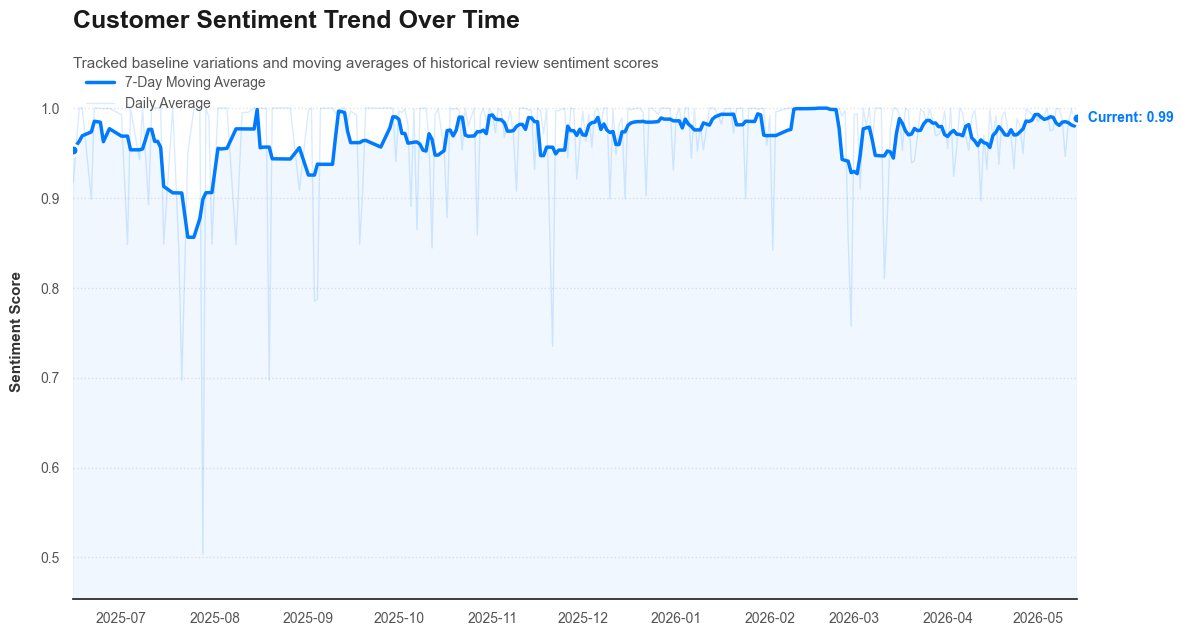

In [33]:
# 1. Parse date and calculate metrics
df["date"] = pd.to_datetime(df["date"])
# Sort by date ensures chronological plotting
trend = df.groupby("date")["sentiment_score"].mean().sort_index()

# Optional but highly recommended: Calculate a 7-day rolling average to smooth out noise
rolling_trend = trend.rolling(window=7, min_periods=1, center=True).mean()

# 2. Set modern aesthetics
sns.set_theme(style="white", context="notebook")  # "white" style for clean backgrounds on lines
plt.rcParams["font.family"] = "sans-serif"

fig, ax = plt.subplots(figsize=(12, 6.5), dpi=100)

# 3. Plot the trend line and shaded area
# Plotting the smoothed rolling trend line
ax.plot(
    rolling_trend.index, 
    rolling_trend.values, 
    color="#007aff",       # Crisp, modern tech-blue
    linewidth=2.5, 
    label="7-Day Moving Average",
    zorder=3
)

# Plotting the raw daily data with high transparency so it stays in the background
ax.plot(
    trend.index, 
    trend.values, 
    color="#007aff", 
    alpha=0.15, 
    linewidth=1, 
    label="Daily Average",
    zorder=2
)

# Add a soft, beautiful gradient-like fill under the trendline
ax.fill_between(
    rolling_trend.index, 
    rolling_trend.values, 
    color="#007aff", 
    alpha=0.06,            # Ultra-subtle fill
    zorder=1
)

# 4. Highlight key milestones (First and Last points)
for idx in [0, -1]:
    ax.scatter(
        rolling_trend.index[idx], rolling_trend.values[idx],
        color="#007aff", edgecolor="white", s=60, linewidth=2, zorder=4
    )
    # Add a text label next to the final point to show the current status
    if idx == -1:
        ax.annotate(
            f" Current: {rolling_trend.values[idx]:.2f}",
            xy=(rolling_trend.index[idx], rolling_trend.values[idx]),
            xytext=(5, -2),
            textcoords="offset points",
            fontweight="bold",
            color="#007aff",
            fontsize=10
        )

# 5. Advanced Typography & Header Layout (Left-Aligned)
min_y, max_y = trend.min(), trend.max()
y_range = max_y - min_y

ax.text(
    x=trend.index.min(), y=max_y + (y_range * 0.18), 
    s="Customer Sentiment Trend Over Time", 
    fontsize=18, fontweight="bold", color="#1a1a1a"
)
ax.text(
    x=trend.index.min(), y=max_y + (y_range * 0.09), 
    s="Tracked baseline variations and moving averages of historical review sentiment scores", 
    fontsize=11, color="#555555"
)

# 6. Axis Styling & Cleanup
ax.set_ylabel("Sentiment Score", fontsize=11, fontweight="semibold", labelpad=12, color="#333333")
# Leaving xlabel empty often looks cleaner on time series because the dates are obvious
ax.set_xlabel("", visible=False) 

# Clean up ticks
ax.tick_params(axis="both", which="major", labelsize=10, colors="#555555")

# Elegant, minimal horizontal lines instead of a full checkerboard grid
ax.grid(axis="x", visible=False)
ax.grid(axis="y", linestyle=":", alpha=0.5, color="#cccccc")

# Dynamically pad the vertical view so line doesn't hit the absolute edges
ax.set_ylim(min_y - (y_range * 0.1), max_y + (y_range * 0.1))
ax.set_xlim(trend.index.min(), trend.index.max())

# 7. Legend Customization
ax.legend(
    loc="upper left", 
    frameon=False, 
    fontsize=10, 
    labelcolor="#555555"
)

# Clean off the top and right border spines
sns.despine(left=True, bottom=False)

plt.tight_layout()
plt.show()

## Key Insights

### Commercial Bank of Ethiopia (CBE)
- Satisfaction drivers:
  - Reliable transactions
  - Easy-to-use interface
- Pain points:
  - OTP/login issues
  - Slow transfer processing

### Bank of Abyssinia (BOA)
- Satisfaction drivers:
  - Good mobile banking features
  - Convenience in usage
- Pain points:
  - App crashes
  - Weak customer support

### Dashen Bank
- Satisfaction drivers:
  - Modern UI design
  - Smooth mobile banking experience
- Pain points:
  - Delayed transactions
  - Update-related bugs

## Product and Support Recommendations

### CBE
- Improve OTP authentication system
- Optimize transaction processing speed

### BOA
- Improve app stability (reduce crashes)
- Strengthen customer support responsiveness

### Dashen Bank
- Improve update testing before release
- Reduce transaction delays during peak usage